In [8]:
import json
import os

import matplotlib.pyplot as plt
import pandas as pd

# Configuración visual
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 12, "lines.linewidth": 2})


# 1. Función para cargar todos los JSON
def cargar_resultados(ruta_base="results/qho"):
    datos = []

    # Recorremos todas las subcarpetas
    for raiz, _, archivos in os.walk(ruta_base):
        for archivo in archivos:
            if archivo.endswith(".json"):
                ruta_completa = os.path.join(raiz, archivo)
                with open(ruta_completa) as f:
                    exp = json.load(f)

                    # Aplanamos la información útil en un solo diccionario
                    fila = exp["config"].copy()
                    fila["error_L2"] = exp["resultados_finales"]["error_L2"]
                    fila["epsilon_final"] = exp["resultados_finales"].get(
                        "epsilon_final", None
                    )
                    fila["epsilon_exacto"] = exp["resultados_finales"].get(
                        "epsilon_exacto", None
                    )

                    # Guardamos el historial completo para poder pintar curvas
                    fila["historial_loss"] = exp["historial"]["total_loss"]
                    fila["historial_epoch"] = exp["historial"]["epoch"]
                    fila["historial_epsilon"] = exp["historial"].get("epsilon", [])

                    datos.append(fila)

    return pd.DataFrame(datos)


# 2. Cargamos el DataFrame
df = cargar_resultados()

print(f"¡Se han cargado {len(df)} experimentos correctamente!")
# Mostramos las primeras columnas para verificar
display(
    df[
        [
            "estado_n",
            "use_physics",
            "use_data",
            "num_train_points",
            "sampler",
            "error_L2",
        ]
    ].head()
)

¡Se han cargado 62 experimentos correctamente!


,estado_n,use_physics,use_data,num_train_points,sampler,error_L2
0,2,False,True,10,lhs,1.347856
1,2,True,True,20,grid,0.699388
2,2,True,True,5,grid,0.975322
3,2,True,True,5,lhs,0.971996
4,2,True,True,10,grid,0.720262


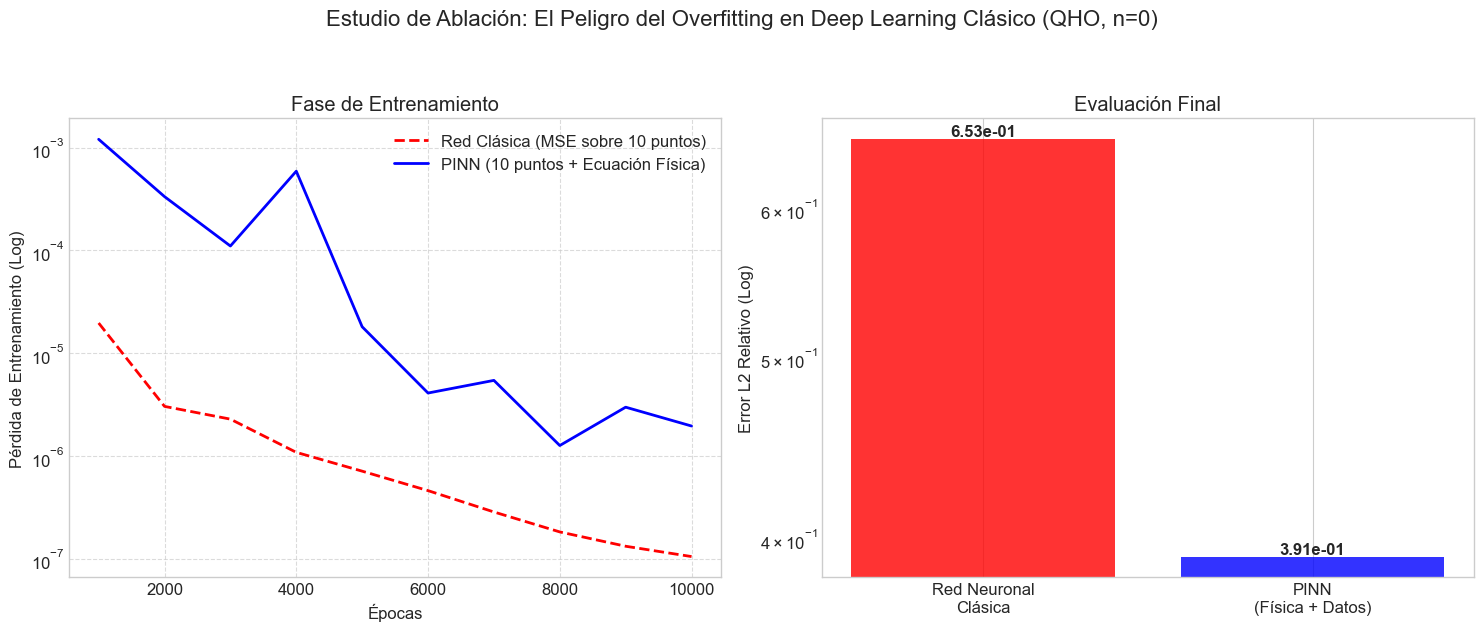

In [10]:
# Filtramos para quedarnos solo con el estado n=0, 10 puntos de entrenamiento y Grid
df_ablacion = df[
    (df["estado_n"] == 1)
    & (df["num_train_points"] == 10)
    & (df["sampler"] == "grid")
    & (df["use_orthogonality"] == False)
]

# Separamos los dos modelos
red_clasica = df_ablacion[df_ablacion["use_physics"] == False].iloc[0]
pinn_supervisada = df_ablacion[
    (df_ablacion["use_physics"] == True) & (df_ablacion["use_data"] == True)
].iloc[0]

# --- DIBUJAMOS 2 PANELES PARA EXPLICAR LA PARADOJA ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# PANEL 1: La trampa del entrenamiento (Loss)
ax1.plot(
    red_clasica["historial_epoch"],
    red_clasica["historial_loss"],
    label="Red Clásica (MSE sobre 10 puntos)",
    color="red",
    linestyle="--",
    linewidth=2,
)

ax1.plot(
    pinn_supervisada["historial_epoch"],
    pinn_supervisada["historial_loss"],
    label="PINN (10 puntos + Ecuación Física)",
    color="blue",
    linewidth=2,
)

ax1.set_yscale("log")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Pérdida de Entrenamiento (Log)")
ax1.set_title("Fase de Entrenamiento")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.7)

# PANEL 2: La realidad de la generalización (Error L2)
modelos = ["Red Neuronal\nClásica", "PINN\n(Física + Datos)"]
errores_l2 = [red_clasica["error_L2"], pinn_supervisada["error_L2"]]
colores = ["red", "blue"]

bars = ax2.bar(modelos, errores_l2, color=colores, alpha=0.8)
ax2.set_yscale("log")
ax2.set_ylabel("Error L2 Relativo (Log)")
ax2.set_title("Evaluación Final")
ax2.grid(True, axis="y", linestyle="--", alpha=0.7)

# Añadimos los valores numéricos encima de las barras
for bar in bars:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        yval,
        f"{yval:.2e}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.suptitle(
    "Estudio de Ablación: El Peligro del Overfitting en Deep Learning Clásico (QHO, n=0)",
    fontsize=16,
    y=1.05,
)
plt.tight_layout()
plt.show()

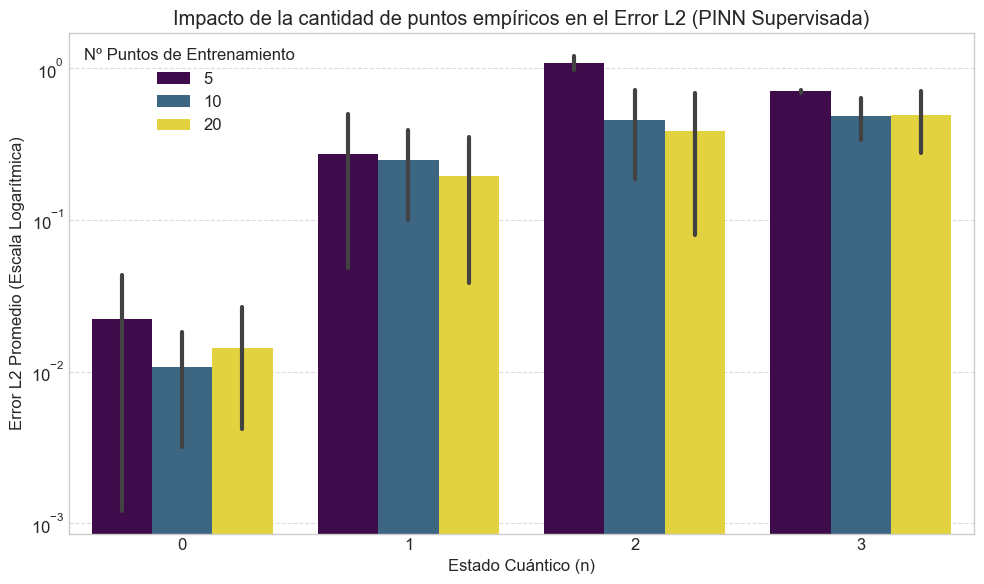

In [4]:
import seaborn as sns

# Filtramos solo las PINNs supervisadas (EXP 2)
df_sup = df[(df["use_data"] == True) & (df["use_physics"] == True)].copy()

plt.figure(figsize=(10, 6))
# Usamos un barplot de Seaborn que automáticamente calcula la media de las combinaciones (sampler, dynamic_weights)
sns.barplot(
    data=df_sup, x="estado_n", y="error_L2", hue="num_train_points", palette="viridis"
)

plt.yscale("log")
plt.title(
    "Impacto de la cantidad de puntos empíricos en el Error L2 (PINN Supervisada)"
)
plt.xlabel("Estado Cuántico (n)")
plt.ylabel("Error L2 Promedio (Escala Logarítmica)")
plt.legend(title="Nº Puntos de Entrenamiento")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

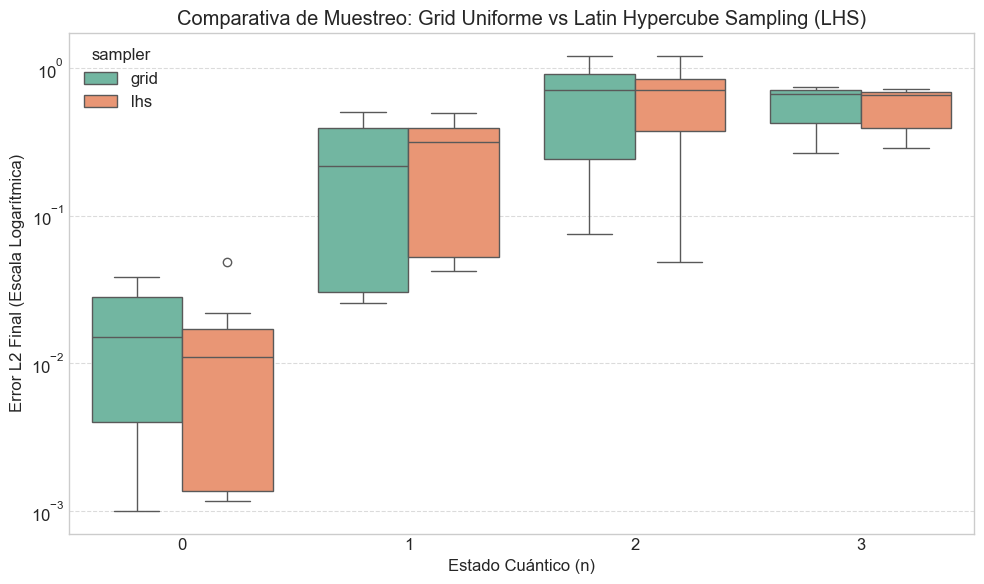

In [ ]:
plt.figure(figsize=(10, 6))

# Boxplot para ver no solo la media, sino la varianza (estabilidad) de cada método
sns.boxplot(data=df_sup, x="estado_n", y="error_L2", hue="sampler", palette="Set2")

plt.yscale("log")
plt.title("Comparativa de Muestreo: Grid Uniforme vs Latin Hypercube Sampling (LHS)")
plt.xlabel("Estado Cuántico (n)")
plt.ylabel("Error L2 Final (Escala Logarítmica)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

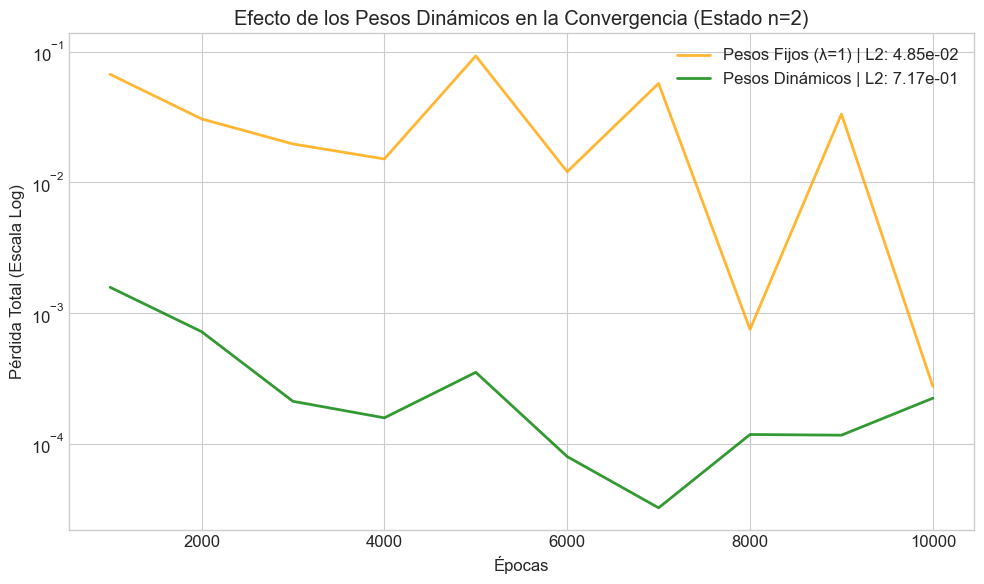

In [ ]:
# Filtramos un caso específico pero difícil
df_dyn = df[
    (df["estado_n"] == 2)
    & (df["num_train_points"] == 10)
    & (df["sampler"] == "lhs")
    & (df["use_data"] == True)
    & (df["use_physics"] == True)
]

pinn_fijos = df_dyn[df_dyn["use_dynamic_weights"] == False].iloc[0]
pinn_dinamicos = df_dyn[df_dyn["use_dynamic_weights"] == True].iloc[0]

plt.figure(figsize=(10, 6))

plt.plot(
    pinn_fijos["historial_epoch"],
    pinn_fijos["historial_loss"],
    label=f"Pesos Fijos (λ=1) | L2: {pinn_fijos['error_L2']:.2e}",
    color="orange",
    alpha=0.8,
)

plt.plot(
    pinn_dinamicos["historial_epoch"],
    pinn_dinamicos["historial_loss"],
    label=f"Pesos Dinámicos | L2: {pinn_dinamicos['error_L2']:.2e}",
    color="green",
    alpha=0.8,
)

plt.yscale("log")
plt.title("Efecto de los Pesos Dinámicos en la Convergencia (Estado n=2)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida Total (Escala Log)")
plt.legend()
plt.tight_layout()
plt.show()

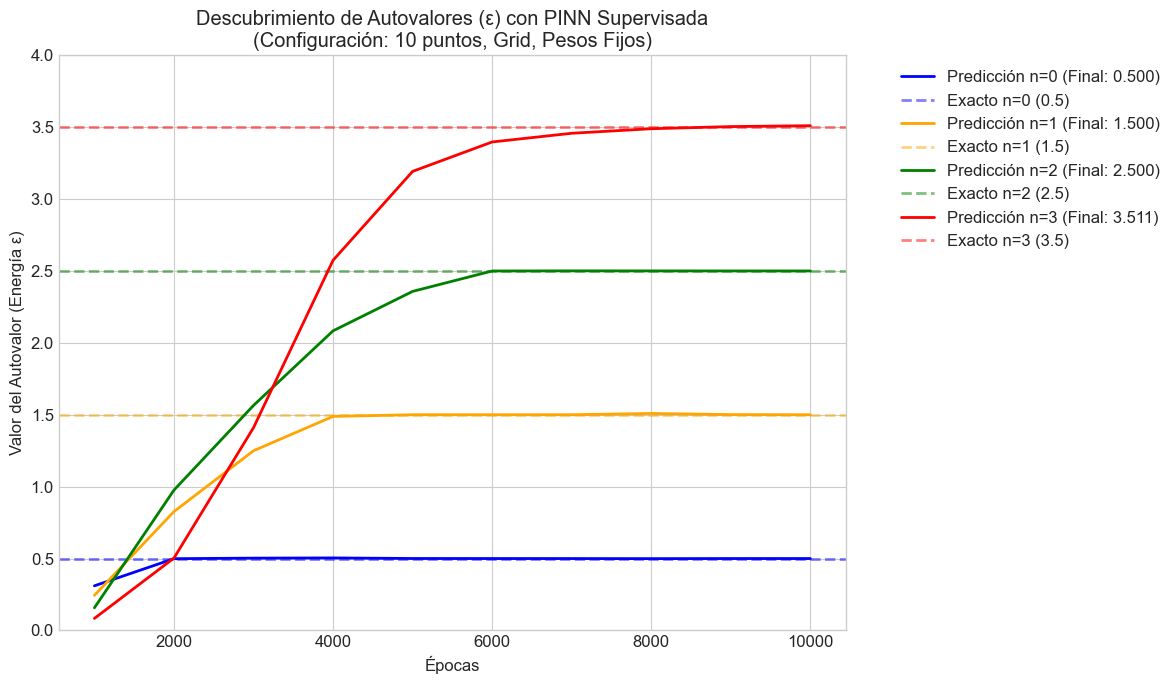

In [ ]:
# Filtramos para quedarnos con UNA ÚNICA configuración básica por estado
df_basic_sup = df[
    (df["use_data"] == True)
    & (df["use_physics"] == True)
    & (df["use_dynamic_weights"] == False)  # Sin pesos dinámicos
    & (df["sampler"] == "grid")  # Muestreo básico
    & (df["num_train_points"] == 10)  # 10 puntos de datos
].sort_values("estado_n")

plt.figure(figsize=(12, 7))

colores = ["blue", "orange", "green", "red"]

# Iteramos sobre los 4 estados (n=0, 1, 2, 3) que cumplen ese filtro
for idx, (_, row) in enumerate(df_basic_sup.iterrows()):
    n = row["estado_n"]
    eps_exacto = row["epsilon_exacto"]
    eps_hist = row["historial_epsilon"]
    epocas = row["historial_epoch"]

    # Curva de lo que la red cree que es la energía a lo largo de las épocas
    plt.plot(
        epocas,
        eps_hist,
        color=colores[idx],
        linewidth=2,
        label=f"Predicción n={n} (Final: {row['epsilon_final']:.3f})",
    )

    # Línea punteada con la verdad absoluta matemática
    plt.axhline(
        y=eps_exacto,
        color=colores[idx],
        linestyle="--",
        alpha=0.5,
        label=f"Exacto n={n} ({eps_exacto})",
    )

plt.title(
    "Descubrimiento de Autovalores (ε) con PINN Supervisada\n(Configuración: 10 puntos, Grid, Pesos Fijos)"
)
plt.xlabel("Épocas")
plt.ylabel("Valor del Autovalor (Energía ε)")
plt.ylim(0, 4.0)

# Movemos la leyenda fuera para que se vean bien las líneas
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()